### <font color='blue'> Machine Learning - Adult Income Dataset

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 

In [156]:
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
adult_df = adult.data.original

### <font color='blue'>Exploratory Data Analysis

In [157]:
adult_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [158]:
adult_df.shape

(48842, 15)

In [159]:
adult_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [160]:
adult_df.describe(include='O')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,47879,48842,48842,47876,48842,48842,48842,48568,48842
unique,9,16,7,15,6,5,2,42,4
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,24720


In [161]:
adult_df.sample(frac=0.2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
43796,36,Private,225516,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Black,Male,0,0,40,United-States,>50K.
3848,28,Private,282398,Some-college,10,Separated,Tech-support,Unmarried,White,Male,0,0,40,United-States,>50K
18856,37,Private,201259,11th,7,Divorced,Transport-moving,Not-in-family,White,Male,0,0,65,United-States,<=50K
19663,51,Private,334273,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
20726,26,Private,357933,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,15,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29337,21,Federal-gov,181096,Some-college,10,Never-married,Tech-support,Own-child,Black,Male,0,0,20,United-States,<=50K
8963,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
24852,20,Local-gov,163965,HS-grad,9,Never-married,Other-service,Unmarried,Black,Female,0,0,40,United-States,<=50K
35636,31,State-gov,268832,HS-grad,9,Never-married,Adm-clerical,Not-in-family,Black,Female,0,0,37,United-States,<=50K.


In [162]:
adult_df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

In [163]:
adult_df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [164]:
adult_df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [165]:
numerical_cols = list(adult_df.select_dtypes(include='number'))
categorical_cols = list(adult_df.select_dtypes(include='object'))

In [166]:
for col in numerical_cols:
    print('Range of values in {} \t {} to {}'.format(col,adult_df[col].min(),adult_df[col].max()))
    
for col in categorical_cols:
    print(col.upper())
    print(adult_df[col].unique())

Range of values in age 	 17 to 90
Range of values in fnlwgt 	 12285 to 1490400
Range of values in education-num 	 1 to 16
Range of values in capital-gain 	 0 to 99999
Range of values in capital-loss 	 0 to 4356
Range of values in hours-per-week 	 1 to 99
WORKCLASS
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked' nan]
EDUCATION
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
MARITAL-STATUS
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
OCCUPATION
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv' nan]
RELATIONSHIP
['Not-in-family' 'Husband' 'Wif

### <font color='blue'> Univariate Analysis </font>
#### <font color='blue'>Univariate analysis is the simplest form of analyzing data, where the focus is on one variable at a time. The goal is to describe, summarize, and find patterns in a single variable without considering relationships with other variables.

#### Types of univariate Analysis
<ol> <li>Categorical (Qualitative) Variables </li>
Analysis techniques:<ul> <li>Frequency tables

<li>Bar charts

<li>Pie charts

<li>Mode
</ul>
  
<li>Numerical (Quantitative) Variables</li>
Analysis techniques:
<ul> 
<li>Measures of central tendency: Mean, Median, Mode

<li>Measures of dispersion: Range, Variance, Standard Deviation, Interquartile Range (IQR)

<li>Distribution: Histograms, Box plots, Density plots

<li>Outlier detection </ul>

<li> Goals of Univariate Analysis
<ul><li>Understand the distribution of the data

<li>Identify central values and spread

<li>Detect outliers

<li>Prepare data for further analysis (like bivariate or multivariate analysis)



###### <font color='blue'> Age Column

In [167]:
adult_df['age'].unique()

array([39, 50, 38, 53, 28, 37, 49, 52, 31, 42, 30, 23, 32, 40, 34, 25, 43,
       54, 35, 59, 56, 19, 20, 45, 22, 48, 21, 24, 57, 44, 41, 29, 18, 47,
       46, 36, 79, 27, 67, 33, 76, 17, 55, 61, 70, 64, 71, 68, 66, 51, 58,
       26, 60, 90, 75, 65, 77, 62, 63, 80, 72, 74, 69, 73, 81, 78, 88, 82,
       83, 84, 85, 86, 87, 89])

In [168]:
adult_df['age'].describe()

count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

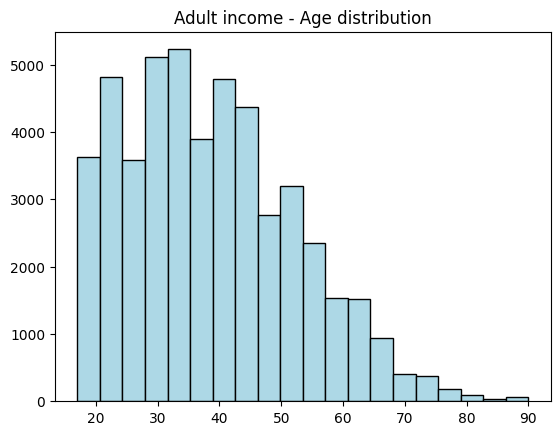

In [169]:
plt.hist(adult_df['age'], bins=20,color='lightblue',edgecolor='black')
plt.title('Adult income - Age distribution')
plt.show()

In [170]:
(adult_df['age']>80).value_counts()

age
False    48694
True       148
Name: count, dtype: int64

In [171]:
(adult_df[adult_df['age']>80])['age'].value_counts()

age
90    55
81    37
82    15
84    13
83    11
88     6
85     5
87     3
89     2
86     1
Name: count, dtype: int64

#### <font color='green'> The age is distributed from 17 to 90, with high frequency from 20 to 50 years, with few values in 80 to 90 years. Though the frequency is less in this age group, there are 148 participants who fall under this category. So there is least of chance of outliers being detected in this column.

###### <font color='blue'> Fnlwgt Column

In [172]:
adult_df['fnlwgt'].value_counts()

fnlwgt
203488    21
120277    19
190290    19
125892    18
126569    18
          ..
374763     1
242136     1
26711      1
117909     1
159691     1
Name: count, Length: 28523, dtype: int64

In [173]:
adult_df['fnlwgt'].describe()

count    4.884200e+04
mean     1.896641e+05
std      1.056040e+05
min      1.228500e+04
25%      1.175505e+05
50%      1.781445e+05
75%      2.376420e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64

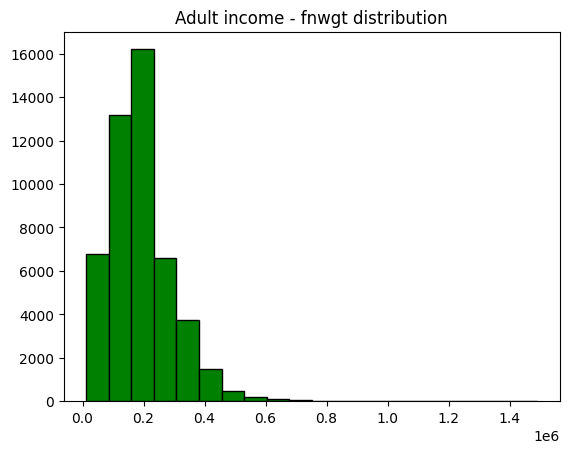

In [174]:
plt.hist(adult_df['fnlwgt'], bins=20,color='green',edgecolor='black')
plt.title('Adult income - fnwgt distribution')
plt.show()

#### <font color='green'> The fnlwgt is distributed from 12285 to 14904 and is right skewed

###### <font color='blue'> Marital-stauts Column

In [175]:
adult_df['marital-status'].value_counts()

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

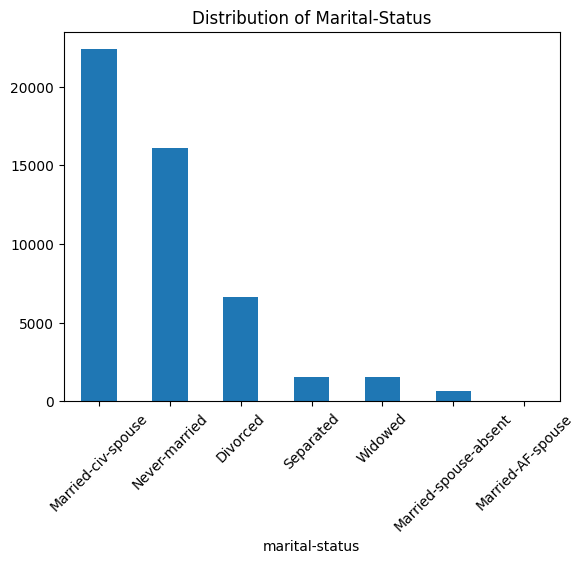

In [176]:
adult_df['marital-status'].value_counts().plot(kind='bar')
plt.title('Distribution of Marital-Status')
plt.xticks(rotation=45)
plt.show()

#### <font color='green'> The column 'marital=status' has 7 independent categories, with 'Married-civ-spouse' is most common. No cleaning or grouping required for this column.

###### <font color='blue'> Relationship Column

In [177]:
adult_df['relationship'].value_counts()

relationship
Husband           19716
Not-in-family     12583
Own-child          7581
Unmarried          5125
Wife               2331
Other-relative     1506
Name: count, dtype: int64

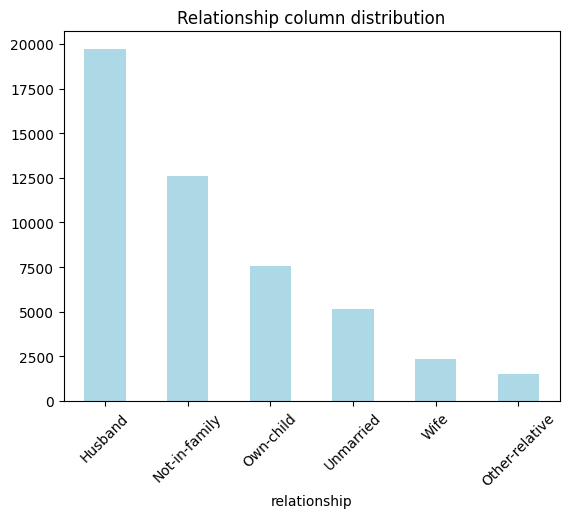

In [178]:
adult_df['relationship'].value_counts().plot(kind='bar',color='lightblue')
plt.title('Relationship column distribution')
plt.xticks(rotation=45)
plt.show()

#### <font color='green'> The column 'relationship' has 6 independent categories, with 'Husband' being the most common. No cleaning or grouping required for this column.

###### <font color='blue'> Race Column

In [179]:
adult_df['race'].value_counts()

race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

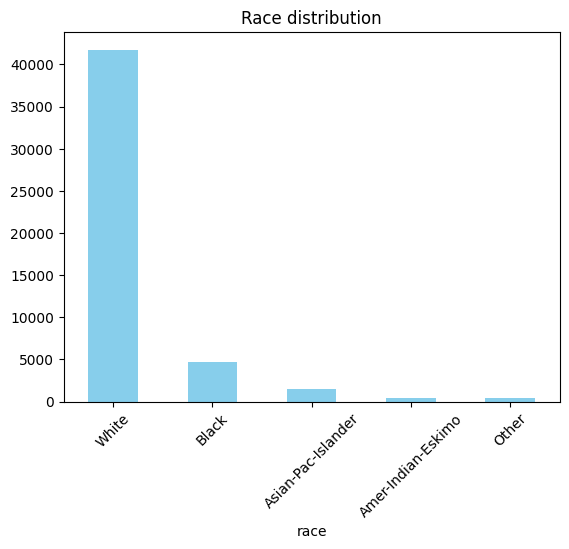

In [180]:
adult_df['race'].value_counts().plot(kind='bar',color='skyblue')
plt.title('Race distribution')
plt.xticks(rotation=45)
plt.show()

#### <font color='green'> The column 'race' has 5 independent categories, with 'White' being the most common. No cleaning or grouping required for this column.

###### <font color='blue'> Sex Column

In [181]:
adult_df['sex'].value_counts()

sex
Male      32650
Female    16192
Name: count, dtype: int64

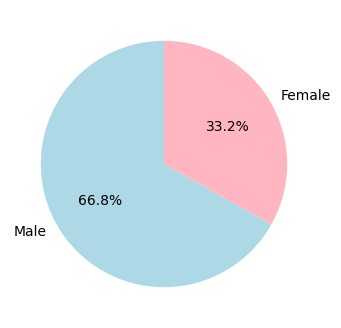

In [182]:
cnt = adult_df['sex'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(cnt, labels=cnt.index, autopct='%1.1f%%', colors=['lightblue', 'lightpink'], startangle=90)
plt.show()

#### <font color='green'> Male population is twice as the female population in our dataset.

###### <font color='blue'> Capital-Gain Column

In [183]:
adult_df['capital-gain'].value_counts()

capital-gain
0        44807
15024      513
7688       410
7298       364
99999      244
         ...  
1639         1
2387         1
7262         1
1731         1
6612         1
Name: count, Length: 123, dtype: int64

In [184]:
adult_df['capital-gain'].describe()

count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

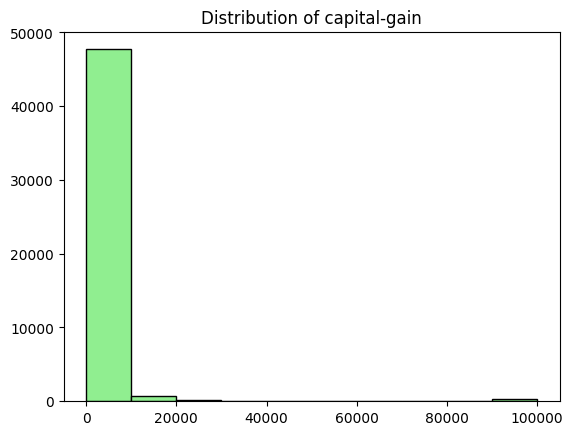

In [185]:
plt.hist(adult_df['capital-gain'],bins=10,edgecolor='black',color='lightgreen')
plt.title('Distribution of capital-gain')
plt.show()

In [186]:
cap_gain = adult_df[adult_df['capital-gain'] > 20000]
cap_gain.shape

(381, 15)

In [187]:
cap_gain['income'].value_counts()

income
>50K      245
>50K.     126
<=50K       8
<=50K.      2
Name: count, dtype: int64

In [188]:
cap_gain = adult_df[adult_df['capital-gain'] > 25000]
cap_gain.shape

(331, 15)

In [189]:
cap_gain['income'].value_counts()

income
>50K      208
>50K.     114
<=50K       7
<=50K.      2
Name: count, dtype: int64

In [190]:
cap_gain['capital-gain'].value_counts()

capital-gain
99999    244
27828     58
25236     14
34095      6
25124      6
41310      3
Name: count, dtype: int64

In [191]:
cap_gain = adult_df[adult_df['capital-gain'] > 50000]
cap_gain.shape

(244, 15)

In [192]:
cap_gain['capital-gain'].value_counts()

capital-gain
99999    244
Name: count, dtype: int64

In [193]:
cap_gain['income'].value_counts()

income
>50K     159
>50K.     85
Name: count, dtype: int64

In [194]:
cap_gain['education'].value_counts()

education
Prof-school     68
Bachelors       63
HS-grad         34
Masters         30
Doctorate       23
Some-college    18
Assoc-voc        3
10th             2
Assoc-acdm       1
9th              1
5th-6th          1
Name: count, dtype: int64

In [195]:
cap_gain.sample(frac=0.3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
13499,50,Private,238959,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,99999,0,60,?,>50K
35533,35,Private,151835,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999,0,50,United-States,>50K.
47011,40,Self-emp-inc,46221,Doctorate,16,Never-married,Prof-specialty,Not-in-family,White,Male,99999,0,55,United-States,>50K.
3105,46,Private,176814,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999,0,50,United-States,>50K
10366,32,Private,204567,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,99999,0,60,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31972,43,Self-emp-inc,62026,Prof-school,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,40,United-States,>50K
22361,43,Private,58447,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999,0,55,United-States,>50K
27221,48,Self-emp-not-inc,107231,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,50,United-States,>50K
39908,65,Private,190160,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,40,United-States,>50K.


#### <font color='green'> The 'Capital-gain' column is completely right skewed, with more than 90% of the values is 0 and less than 1% of the rows have the 'capital-gain' of > 20000. 244 rows have the capital-gain of 99999 which may or may not be a possible outlier. But these rows have the correct corresponding value (>50K) in the 'income' column. The values in other columns are also distributed, means the same values are not repeated.

###### <font color='blue'> Capital-Loss Column

In [196]:
adult_df['capital-loss'].value_counts()

capital-loss
0       46560
1902      304
1977      253
1887      233
2415       72
        ...  
2201        1
1870        1
1911        1
2465        1
1421        1
Name: count, Length: 99, dtype: int64

In [197]:
adult_df['capital-loss'].describe()

count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

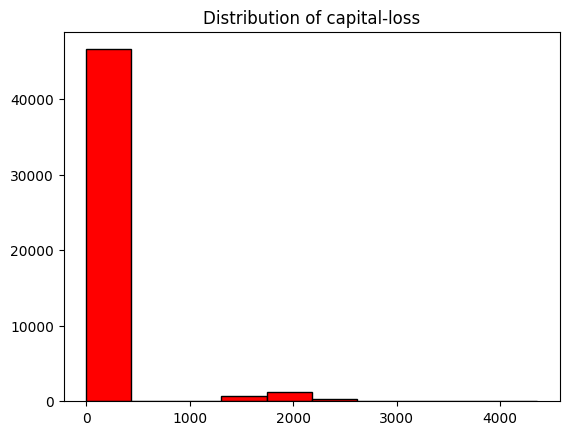

In [198]:
plt.hist(adult_df['capital-loss'],bins=10,edgecolor='black',color='red')
plt.title('Distribution of capital-loss')
plt.show()

In [199]:
cap_loss = adult_df[adult_df['capital-loss'] > 2000]
cap_loss.shape

(491, 15)

In [200]:
cap_loss['capital-loss'].unique()

array([2042, 2179, 2206, 2339, 2415, 2051, 2377, 2352, 2392, 2001, 2002,
       2258, 2547, 2174, 2205, 2444, 2238, 3004, 2231, 2824, 2559, 2057,
       2149, 2129, 2603, 2282, 4356, 2246, 2489, 3770, 3683, 2267, 2080,
       2457, 3900, 2201, 2467, 2163, 2754, 2472, 3175, 2465])

In [201]:
cap_loss['income'].value_counts()

income
<=50K     183
>50K      142
<=50K.    102
>50K.      64
Name: count, dtype: int64

#### <font color='green'> The 'Capital-loss' column is right skewed, with more than 95% of the values being 0. The other values are distributed between 1500 and 4500.

###### <font color='blue'> Hours-per-week Column

In [202]:
adult_df['hours-per-week'].value_counts()

hours-per-week
40    22803
50     4246
45     2717
60     2177
35     1937
      ...  
87        1
82        1
94        1
79        1
69        1
Name: count, Length: 96, dtype: int64

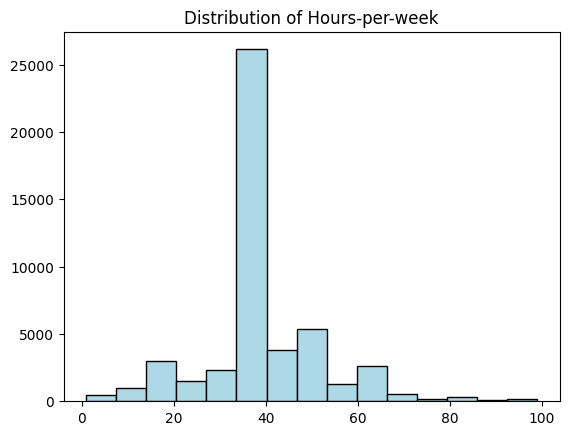

In [203]:
plt.hist(adult_df['hours-per-week'],bins=15,edgecolor='black',color='lightblue')
plt.title('Distribution of Hours-per-week')
plt.show()

#### <font color='green'> In the 'hours-per-week' column, more than 50% of the values is 40 which is nominal for most of the jobs. The values > 70 may need further analysis.

###### <font color='blue'> Workclass Column

In [204]:
adult_df['workclass'].value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

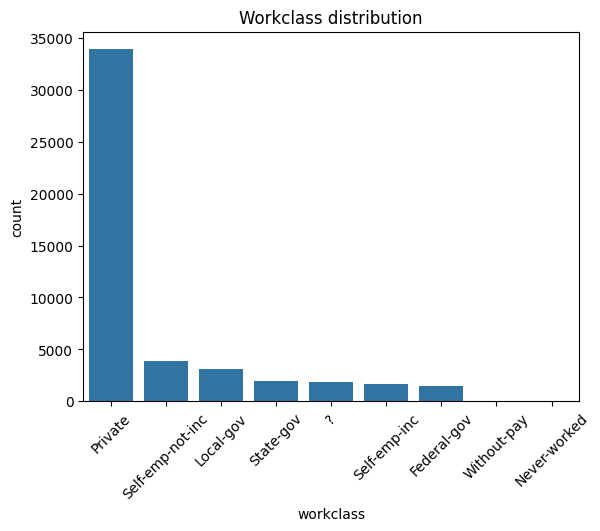

In [205]:
sns.countplot(data=adult_df, x='workclass', order=adult_df['workclass'].value_counts().index)
plt.title('Workclass distribution')
plt.xticks(rotation=45)
plt.show()

#### <font color='green'> The workclass categories are widely distributed with 2/3rd of the data being 'Private' and the categories 'Without-pay' and 'Never-worked' having least values. There are null values in this column, and also the inconsistent value '?'.

###### <font color='blue'> Education Column

In [206]:
adult_df['education'].value_counts()

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

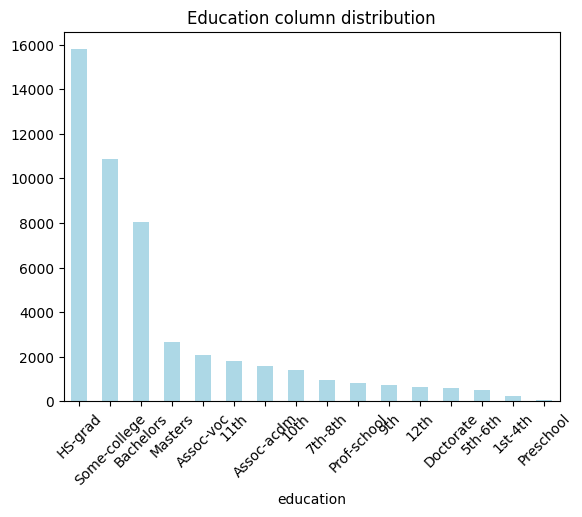

In [207]:
adult_df['education'].value_counts().plot(kind='bar',color='lightblue')
plt.title('Education column distribution')
plt.xticks(rotation=45)
plt.show()

#### <font color='green'> The education categories are widely distributed with 1/3rd of the data being 'HS-grad' and 'Preschool' category is negligible.

###### <font color='blue'> Education-num Column

In [208]:
adult_df['education-num'].value_counts()

education-num
9     15784
10    10878
13     8025
14     2657
11     2061
7      1812
12     1601
6      1389
4       955
15      834
5       756
8       657
16      594
3       509
2       247
1        83
Name: count, dtype: int64

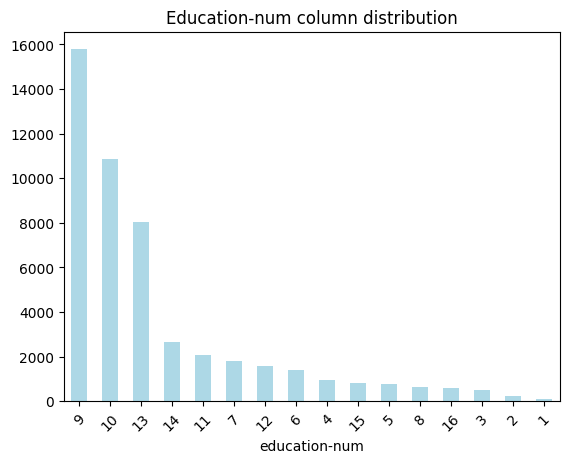

In [209]:
adult_df['education-num'].value_counts().plot(kind='bar',color='lightblue')
plt.title('Education-num column distribution')
plt.xticks(rotation=45)
plt.show()

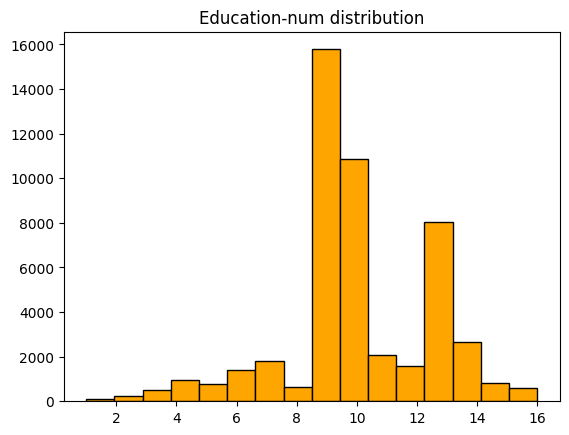

In [210]:
plt.hist(adult_df['education-num'],bins=16,color='orange',edgecolor='black')
plt.title('Education-num distribution')
plt.show()

#### <font color='green'> The education-num column is duplicate of the education column with categories being replaced with numbers.

###### <font color='blue'> Occupation Column

In [211]:
adult_df['occupation'].value_counts()

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
?                    1843
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

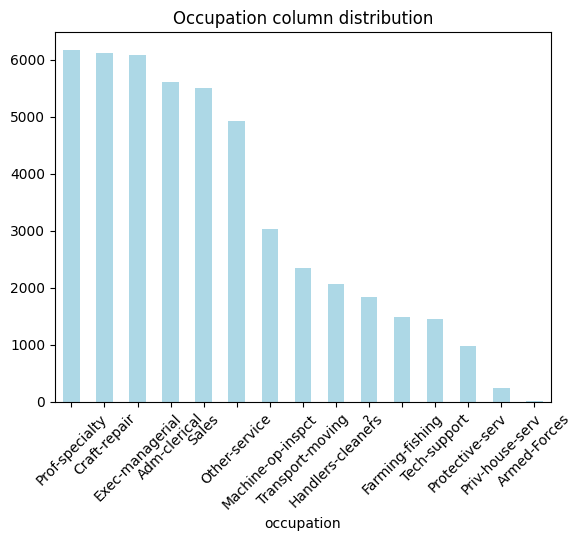

In [212]:
adult_df['occupation'].value_counts().plot(kind='bar',color='lightblue')
plt.title('Occupation column distribution')
plt.xticks(rotation=45)
plt.show()

#### <font color='green'> The occupation categories are widely distributed and balanced. There are null values in this column, and also the inconsistent value '?'.

###### <font color='blue'> Native-country Column

In [213]:
adult_df['native-country'].value_counts()   

native-country
United-States                 43832
Mexico                          951
?                               583
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru         

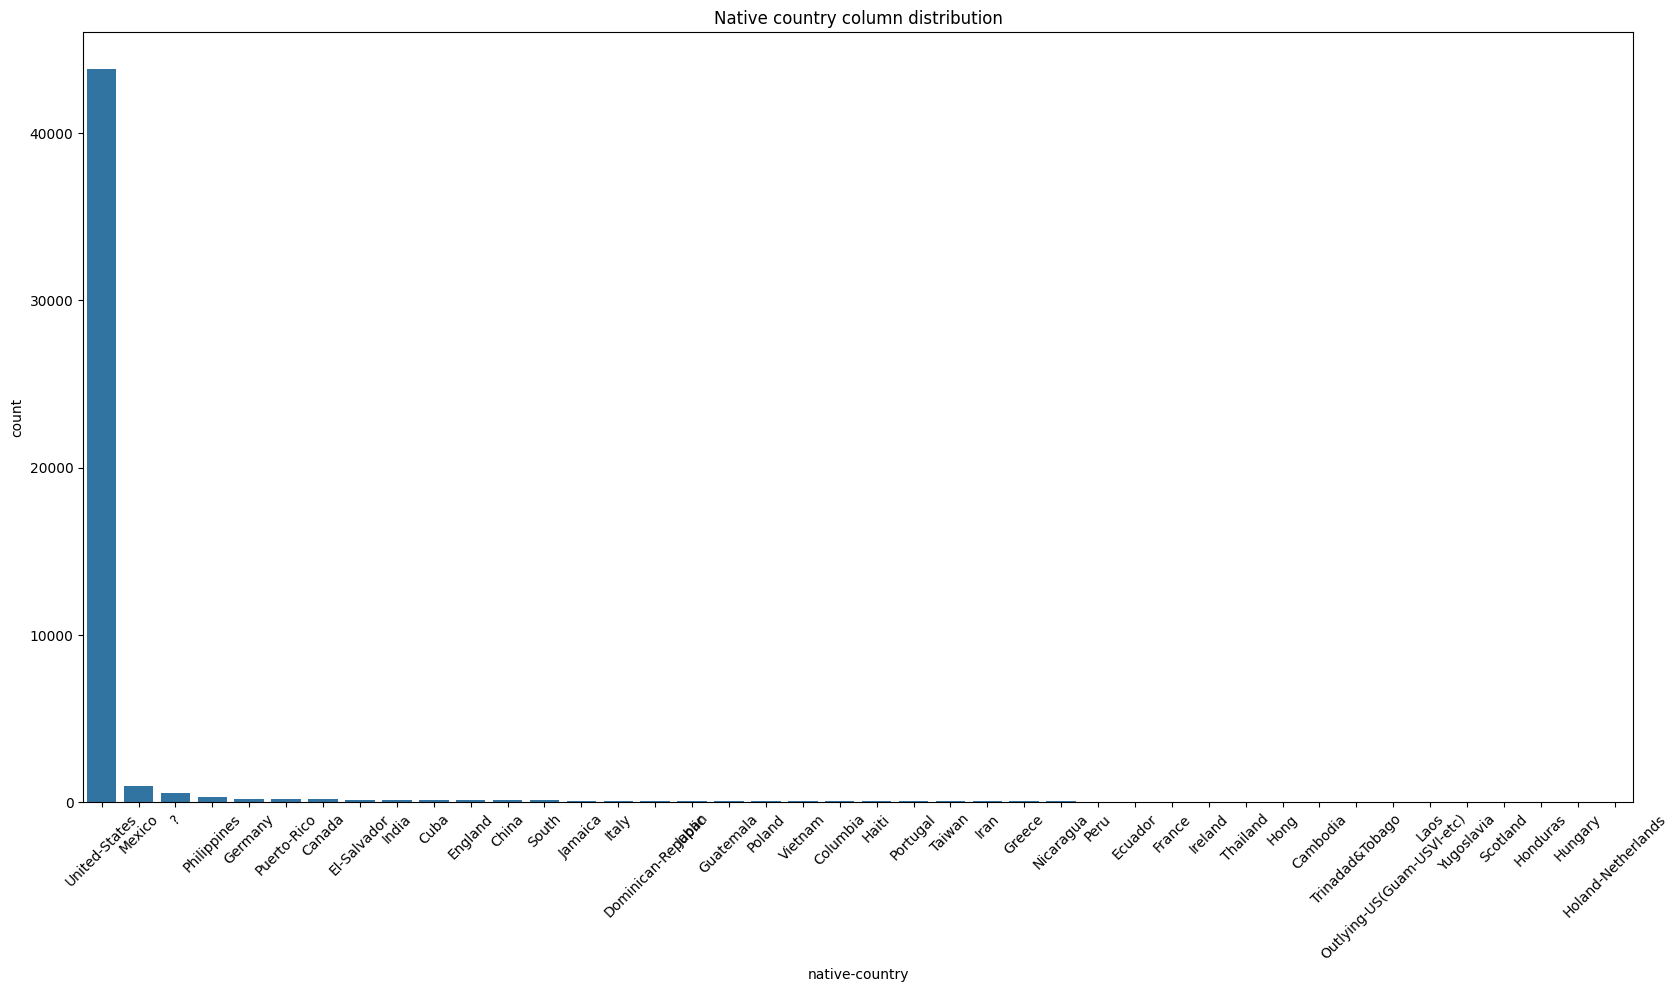

In [214]:
plt.figure(figsize=(20,10))
sns.countplot(data=adult_df, x='native-country', order=adult_df['native-country'].value_counts().index)
plt.title('Native country column distribution')
plt.xticks(rotation=45)
plt.show()

#### <font color='green'> 90% of the data's native-country is 'United States'. This shows that the 'native-country' column will have very less impact on the target variable.

###### <font color='blue'> Income Column

In [215]:
adult_df['income'].value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

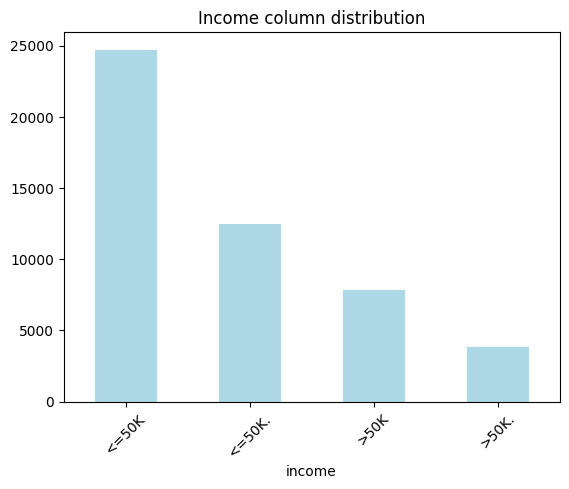

In [216]:
adult_df['income'].value_counts().plot(kind='bar',color='lightblue')
plt.title('Income column distribution')
plt.xticks(rotation=45)
plt.show()

#### <font color='green'> The target column 'income' has inconsistent values.

##### <font color='blue'> Check for duplicate rows

In [217]:
duplicated_rows = adult_df[adult_df.duplicated()]
duplicated_rows.shape

(29, 15)

##### Get the number of rows that has atleast one null value

In [218]:
null_rows = adult_df[adult_df.isnull().any(axis=1)]
null_rows.shape

(1221, 15)

#### Lets do label encoding to find the correlation of the columns 

### <font color='blue'>Label Encoding
   <font color='blue'> Label Encoding is a technique that is used to convert categorical columns into numerical ones so that they can be fitted by machine learning models which only take numerical data. It is an important pre-processing step in a machine-learning project. It assigns a unique integer to each category in the data, making it suitable for machine learning models that work with numerical inputs.

In [219]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Apply label encoding
label_encoder = LabelEncoder()
df_encoded = adult_df.apply(label_encoder.fit_transform)

In [220]:
# Compute correlation of the dataframe with the target column 'income'
df_encoded.corr()['income']

age               0.205173
workclass         0.085754
fnlwgt           -0.006311
education         0.068523
education-num     0.291074
marital-status   -0.171481
occupation        0.091541
relationship     -0.223432
race              0.064000
sex               0.187216
capital-gain      0.295589
capital-loss      0.139770
hours-per-week    0.200008
native-country    0.038546
income            1.000000
Name: income, dtype: float64

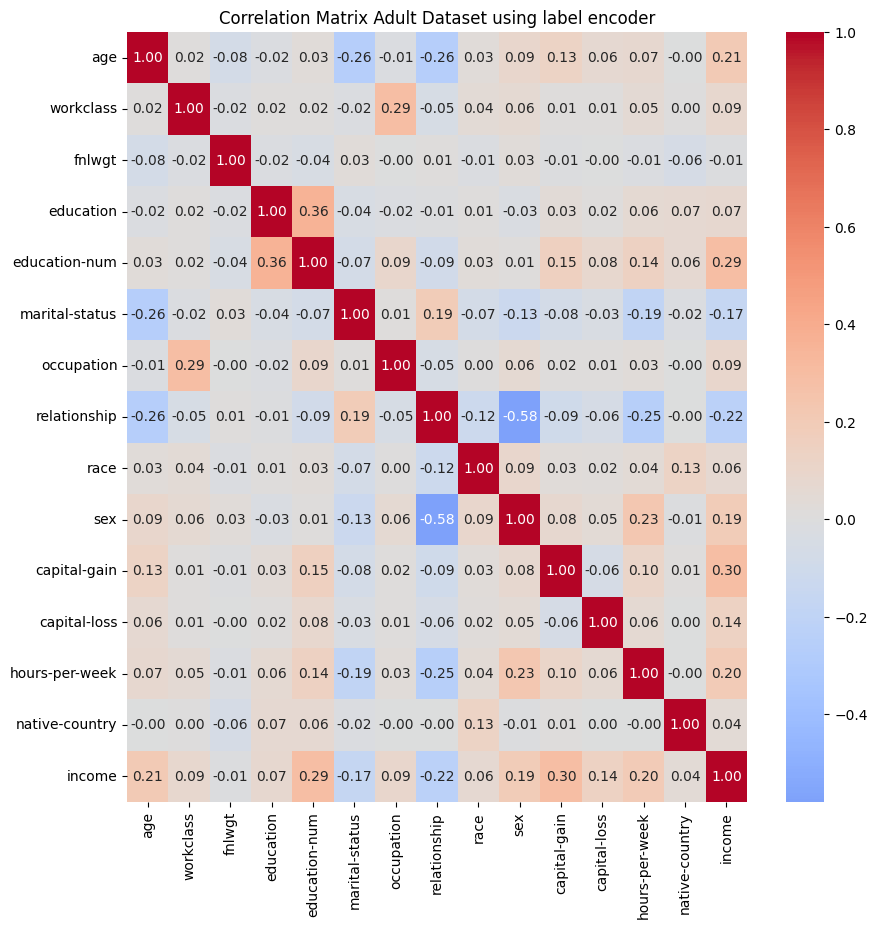

In [221]:
c_matrix = df_encoded.corr()
plt.figure(figsize=(10, 10))

# Generate a heatmap
sns.heatmap(c_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)

# Display the plot
plt.title('Correlation Matrix Adult Dataset using label encoder')
plt.show()

##### calculate the corelation of 'native-country' with other columns

In [222]:
for col in df_encoded.columns:
    correlation = df_encoded[col].corr(df_encoded['native-country'])
    print('{} - {}'.format(col,correlation))

age - -0.0025163150921860447
workclass - 0.0015996699898076893
fnlwgt - -0.056929085513908205
education - 0.06618109706982765
education-num - 0.06245745484576194
marital-status - -0.019584286092771772
occupation - -0.003212659510752861
relationship - -0.003897100244734162
race - 0.13062018345529908
sex - -0.008982922083038365
capital-gain - 0.007699742016255485
capital-loss - 0.00013552169928988898
hours-per-week - -0.00037653409528217964
native-country - 1.0
income - 0.03854647285435655


##### calculate the corelation of 'workclass' with other columns

In [223]:
for col in df_encoded.columns:
    correlation = df_encoded[col].corr(df_encoded['workclass'])
    print('{} - {}'.format(col,correlation))   

age - 0.01624760468085433
workclass - 0.9999999999999999
fnlwgt - -0.024254823748280356
education - 0.01566412935469023
education-num - 0.01543564898636124
marital-status - -0.021335794052605467
occupation - 0.2912239554508624
relationship - -0.04799352904282933
race - 0.043965175920955384
sex - 0.0587748459501669
capital-gain - 0.00989878692348721
capital-loss - 0.010076613369563527
hours-per-week - 0.05245324706908177
native-country - 0.0015996699898076895
income - 0.08575379306012747


##### calculate the corelation of 'occupation' with other columns

In [224]:
for col in df_encoded.columns:
    correlation = df_encoded[col].corr(df_encoded['occupation'])
    print('{} - {}'.format(col,correlation))

age - -0.014721427410372636
workclass - 0.2912239554508624
fnlwgt - -0.0011689074597346178
education - -0.02151463101364363
education-num - 0.0879773255652092
marital-status - 0.009485531014616914
occupation - 1.0
relationship - -0.05115423884319596
race - 0.0015035337319865975
sex - 0.05711895370110713
capital-gain - 0.01642360145455382
capital-loss - 0.014978481630849243
hours-per-week - 0.029454843901192802
native-country - -0.003212659510752861
income - 0.09154089163665512


##### <font color='green'><b> Based on the label encoding, and its correlation matrix, its clear that, the independent features have less correlation with the target. The features 'capital-gain' and 'education-num' have the highest correlation with the target 'income'.

### <font color='green'>Data cleaning suggestions based on the observations from EDA, univariate analysis, and label encoding </font>
<font color='green'> 
     <ol>
        <li>Delete duplicate rows - 29 duplicate rows are there in the dataset </li>
        <li>‘Income’ column has 4 values - <=50K, <=50K., >50K, >50K. - Need to make the values consistent across the dataset </li>
        <li>‘Workclass’, ‘occupation’ and ‘native-country’ columns have inconsistent data ‘?’. Replace them with ‘null’</li>
        <li> When, ‘Workclass’ == never-worked, the ‘occupation’ can be 'None'</li>
        <li>Fill the null values of 'native-country' column based on 'race' column</li>
        <li>Group rare categories of the 'native-country' column and mark it as 'others' </li>
        <li>Fill the null values of 'workclass' column based on 'education' column</li>
        <li>Fill the null values of 'occupation' column based on 'workclass' column</li>
        <li>Group rare categories of the 'occupation' column and add them to the 'other-services' </li>
        <li>Change the datatype of object columns to category </li>
         <li>Standardize the categorical columns </li>
         <li>Map the values of 'gender' column to 0 and 1 and change the datatype to boolean</li>
         <li>Map the values of 'income' column to 0 and 1 and change the datatype to boolean</li>
</ol> </font>

### <font color='blue'> Data Cleaning

##### 1. Delete duplicate rows - 29 duplicate rows are there in the dataset

In [ ]:
# Delete duplicate rows - 29 duplicate rows are there in the dataset
adult_df.drop_duplicates(inplace=True)

# Replace the inconsistent values in 'income' column
replace_dict = {'<=50K.':'<=50K', '>50K.':'>50K' }
adult_df['income'] = adult_df['income'].replace(replace_dict)

# replace '?' with null
adult_df = adult_df.replace('?',np.nan)

fill_values = {'Never-worked': 'No Job'}
adult_df['occupation'] = adult_df['occupation'].fillna(adult_df['workclass'].map(fill_values))

# Group rare native-country values into 'other'
top_countries = adult_df['native-country'].value_counts().nlargest(10).index
adult_df['native-country'] = adult_df['native-country'].apply(lambda x: x if x in top_countries else 'other')


In [225]:
adult_df.drop_duplicates(inplace=True)

##### 2. ‘Income’ column has 4 values - <=50K, <=50K., >50K, >50K. - Need to make the values consistent across the dataset

In [226]:
replace_dict = {'<=50K.':'<=50K', '>50K.':'>50K' }
adult_df['income'] = adult_df['income'].replace(replace_dict)

##### 3. ‘Workclass’, ‘occupation’ and ‘native-country’ columns have inconsistent data ‘?’. Replace them with ‘null’

In [227]:
adult_df = adult_df.replace('?',np.nan)

##### Get the dataframe in which both 'workclass' and 'occupation' are null

In [228]:
df = null_rows[null_rows['workclass'].isna() & null_rows['occupation'].isna()]
df.shape

(963, 15)

##### 4. When, ‘Workclass’ == never-worked, the ‘occupation’ can be 'None'

In [229]:
fill_values = {'Never-worked': 'No Job'}
adult_df['occupation'] = adult_df['occupation'].fillna(adult_df['workclass'].map(fill_values))

##### 5. Fill the null values of 'native-country' column based on 'race' column

In [230]:
adult_df['native-country'] = adult_df.groupby('race')['native-country'].ffill()

##### 6. Group rare categories of the 'native-country' column and mark it as 'others'

In [231]:
# Group rare native-country values into 'other'
top_countries = adult_df['native-country'].value_counts().nlargest(10).index
adult_df['native-country'] = adult_df['native-country'].apply(lambda x: x if x in top_countries else 'other')

##### 7. Fill the null values of 'workclass' column based on 'education' column

In [232]:
adult_df['workclass'] = adult_df.groupby('education')['workclass'].ffill()

##### 8. Fill the null values of 'occupation' column based on 'workclass' column

In [233]:
adult_df['occupation'] = adult_df.groupby('workclass')['occupation'].ffill()

##### 9. Group rare categories of the 'occupation' column and add them to the 'other-services'

In [234]:
# Group rare occupation values into 'other-service'
top_occupation = adult_df['occupation'].value_counts().nlargest(10).index
adult_df['occupation'] = adult_df['occupation'].apply(lambda x: x if x in top_occupation else 'Other-service')

##### 10. Change the datatype of object columns to category

In [235]:
for col in categorical_cols:
    adult_df[col] = adult_df[col].astype('category')

##### 11. Standardize the categorical columns

In [236]:
for col in categorical_cols:
    adult_df[col] = adult_df[col].str.strip().str.lower()

##### 12. Map the values of gender column to 0 and 1 and change the datatype to boolean

In [237]:
sex_dict={'female':0,'male':1}
adult_df['sex']=adult_df['sex'].map(sex_dict)
adult_df['sex'] = adult_df['sex'].astype('bool')

##### 13. Map the values of income column to 0 and 1 and change the datatype to boolean

In [238]:
income_dict={'<=50k':0,'>50k':1}
adult_df['income']=adult_df['income'].map(income_dict)
adult_df['income'] = adult_df['income'].astype('bool')

In [239]:
adult_df['income'].value_counts()

income
False    37128
True     11685
Name: count, dtype: int64

#### After Data Cleaning

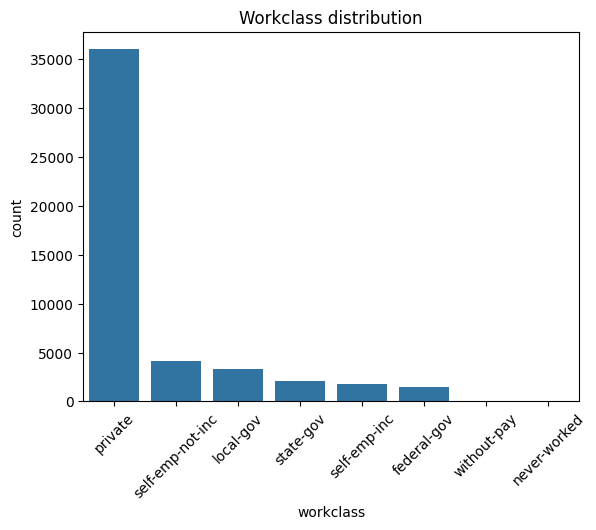

In [240]:
sns.countplot(data=adult_df, x='workclass', order=adult_df['workclass'].value_counts().index)
plt.title('Workclass distribution')
plt.xticks(rotation=45)
plt.show()

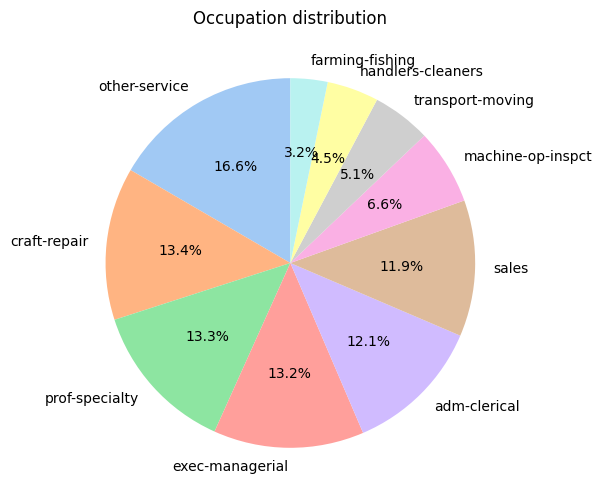

In [241]:
cnt = adult_df['occupation'].value_counts()
plt.figure(figsize=(8, 6))
colors = sns.color_palette('pastel')
plt.pie(cnt, labels=cnt.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Occupation distribution')
plt.show()

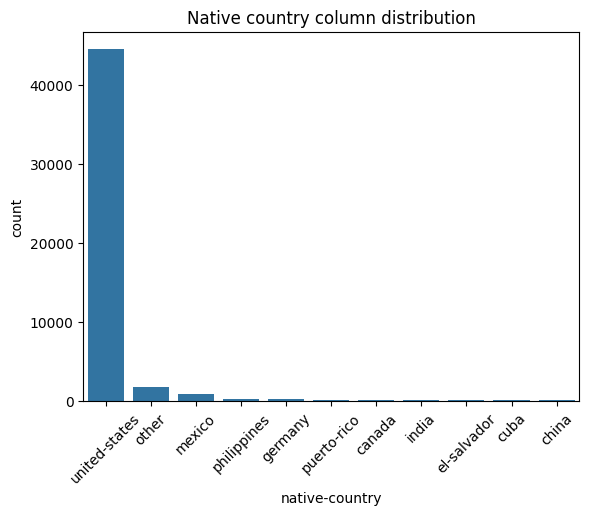

In [242]:
sns.countplot(data=adult_df, x='native-country', order=adult_df['native-country'].value_counts().index)
plt.title('Native country column distribution')
plt.xticks(rotation=45)
plt.show()

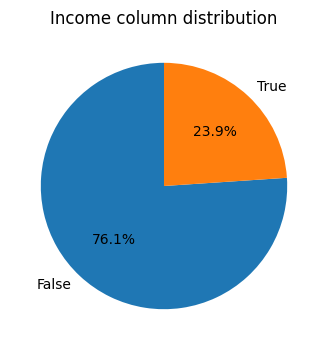

In [243]:
cnt = adult_df['income'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(cnt, labels=cnt.index, autopct='%1.1f%%', startangle=90)
plt.title('Income column distribution')
plt.show()

### <font color='blue'>Bivariate Analysis

#### Bivariate analysis investigates the relationship between two variables. The goal is to determine if and how one variable influences or correlates with another.
#### For the adult income dataset, let us analyze the following pairs:
<ul>
    <li> age vs income </li>
    <li> workclass vs income </li>
    <li> education-num vs income </li>
    <li> capital-gain vs income </li>
    <li> capital-loss vs income </li>
    <li> workclass vs occupation </li>
    <li> age vs hours-per-week </li>
    <li> hours-per-week  vs income </li>
    <li> sex vs income </li>

#### <font color='blue'> Age vs Income

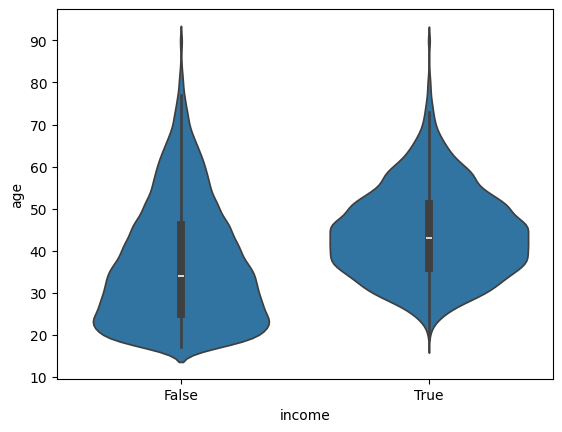

In [244]:
sns.violinplot(data=adult_df, x='income', y='age')
plt.show()

#### <font color='blue'> Workclass vs Income

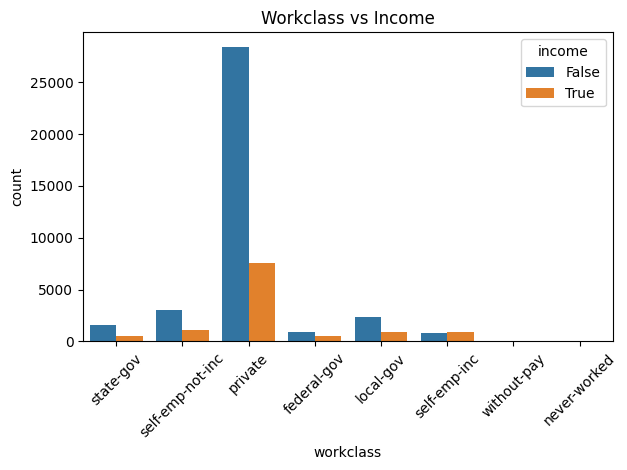

In [245]:
sns.countplot(data=adult_df, x='workclass', hue='income')
plt.xticks(rotation=45)
plt.title('Workclass vs Income')
plt.tight_layout()
plt.show()

#### <font color='blue'> Education-num vs Income

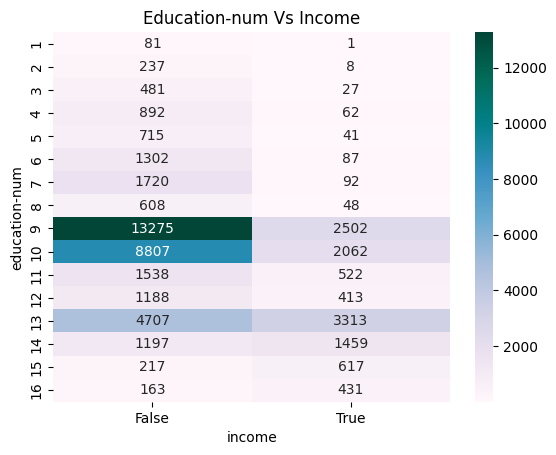

In [246]:
ct = pd.crosstab(adult_df['education-num'], adult_df['income'])
# Plot heatmap
sns.heatmap(ct, annot=True, fmt='d', cmap='PuBuGn')
plt.title('Education-num Vs Income')
plt.show()

#### <font color='blue'> Capital-gain vs Income

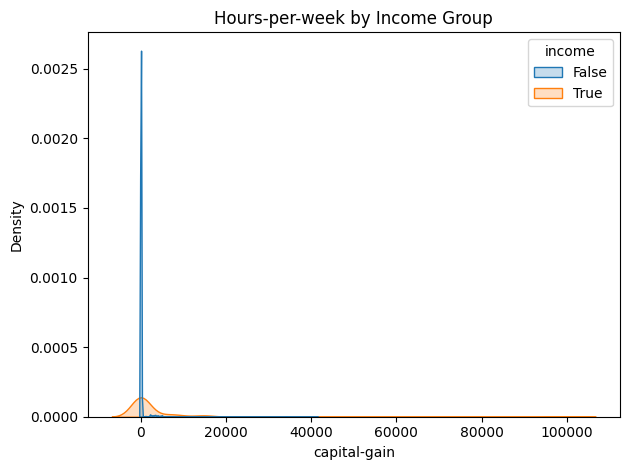

In [247]:
sns.kdeplot(data=adult_df, x='capital-gain', hue='income', fill=True, common_norm=False)

plt.title('Hours-per-week by Income Group')
plt.tight_layout()
plt.show()

#### <font color='blue'> Capital-loss vs Income

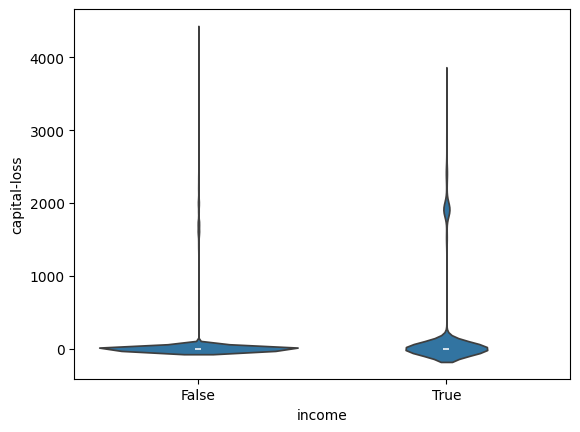

In [248]:
sns.violinplot(data=adult_df, x='income', y='capital-loss')
plt.show()

#### <font color='blue'> Workclass vs Occupation

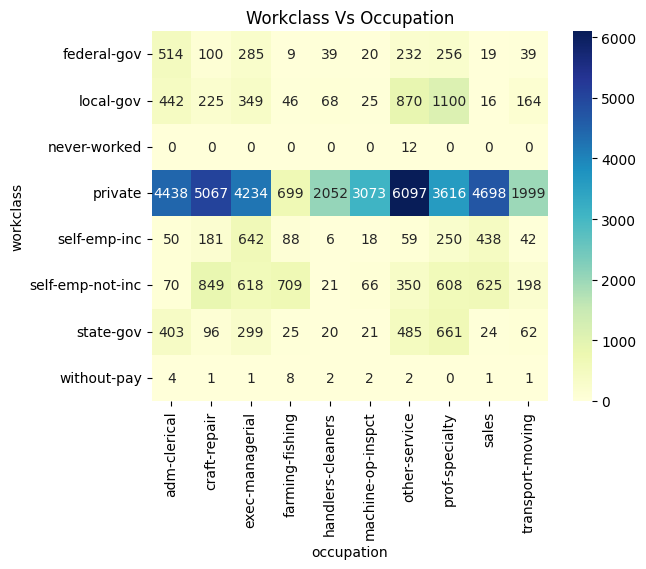

In [249]:
ct = pd.crosstab(adult_df['workclass'], adult_df['occupation'])

# Plot heatmap
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Workclass Vs Occupation')
plt.show()

#### <font color='blue'> Age vs Hours-per-week

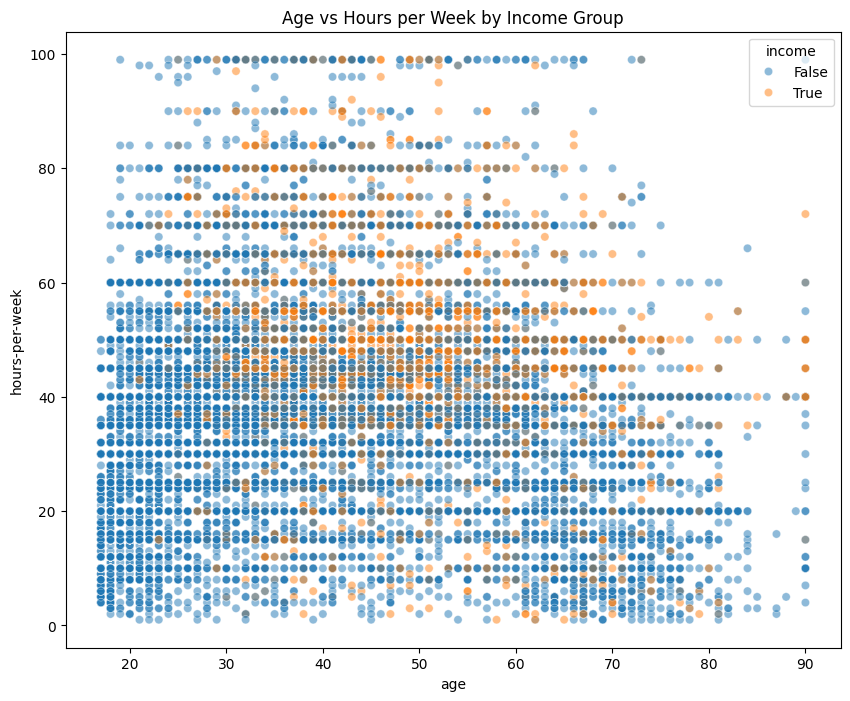

In [250]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=adult_df, x='age', y='hours-per-week', hue='income', alpha=0.5)
plt.title('Age vs Hours per Week by Income Group')
plt.show()

#### <font color='blue'> Hours-per-week vs Income

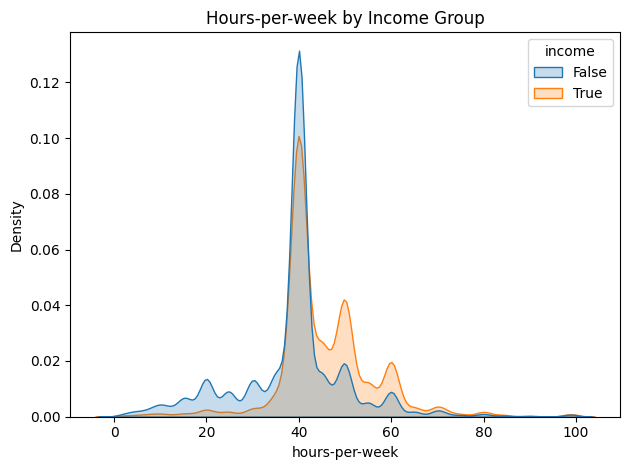

In [251]:
sns.kdeplot(data=adult_df, x='hours-per-week', hue='income', fill=True, common_norm=False)

plt.title('Hours-per-week by Income Group')
plt.tight_layout()
plt.show()

#### <font color='blue'> Gender vs Income

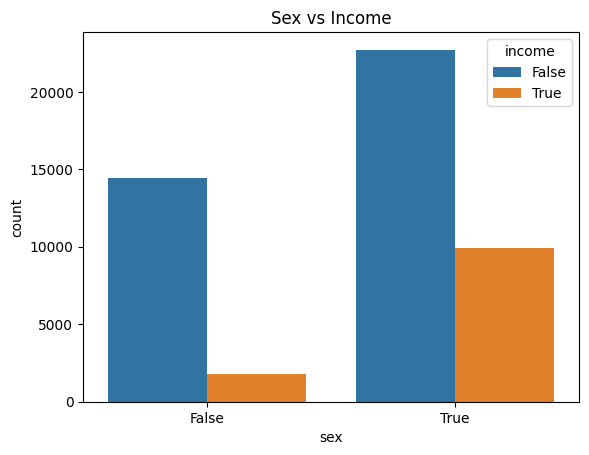

In [252]:
sns.countplot(data=adult_df, x='sex', hue='income')
plt.title('Sex vs Income')
plt.show()

### <font color='blue'> Outlier Detection </font>
##### An Outlier is a data item/object that deviates significantly from the rest of the (so-called normal) objects. Identifying outliers is important in statistics and data analysis because they can have a significant impact on the results of statistical analyses. The analysis for outlier detection is referred to as outlier mining. Outliers can skew the mean (average) and affect measures of central tendency, as well as influence the results of tests of statistical significance.Detecting outliers depends on the type of data and context, but here are the most common and effective methods, especially for numerical features. 
Methods to detect outliers are:
<ol>
    <li>Interquartile Range (IQR) Method </li>
    <li>Z-Score Method </li>
    <li>Visuals - Boxplot </li>
    <li>Isolation Forest / One class SVM </li>
    <li>DBSCAN </li>
</ol>

#### <font color='blue'> 1. Boxplot Method

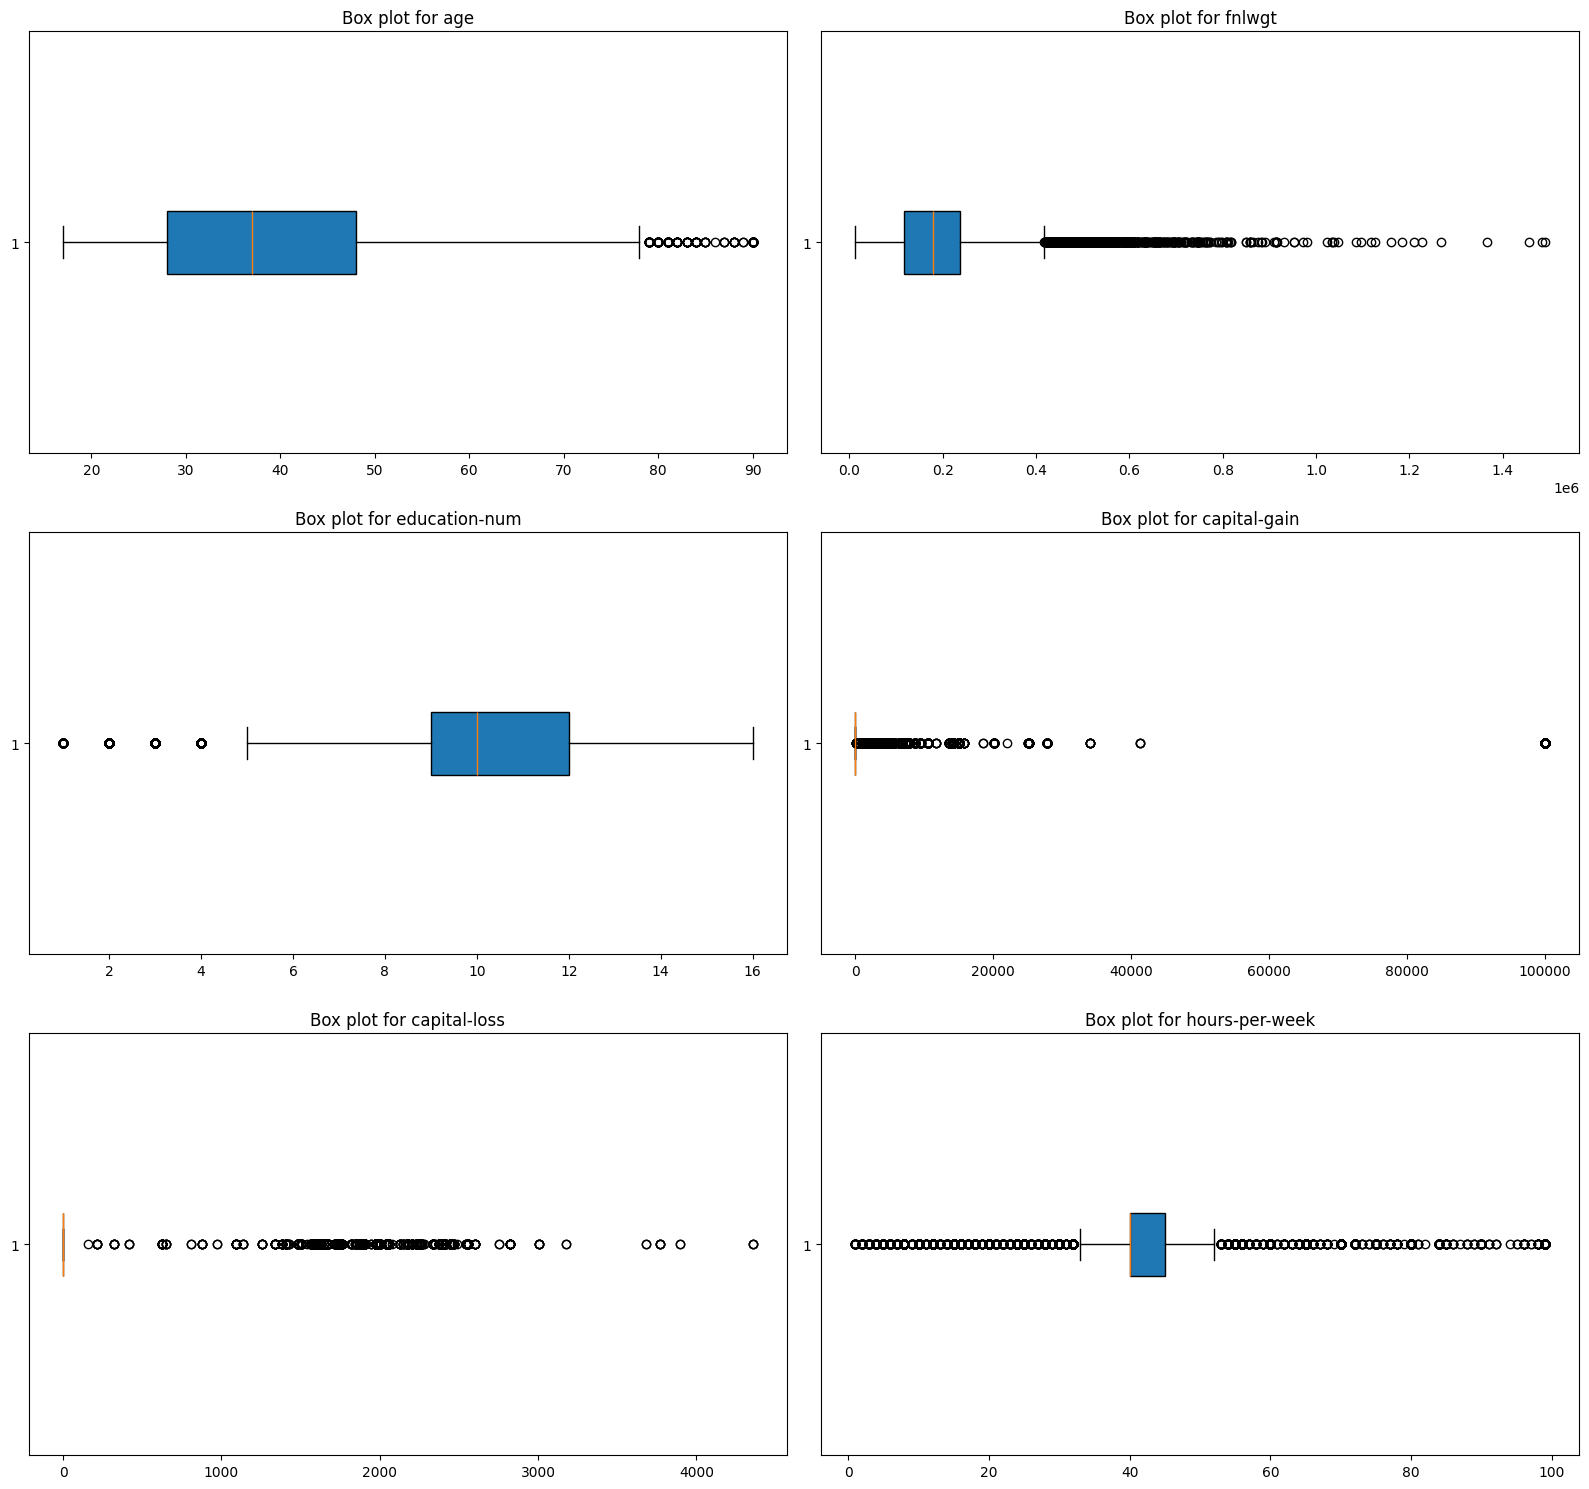

In [253]:
numerical_columns=list(adult_df.select_dtypes(include='number'))
fig, axes = plt.subplots(3,2,figsize=(16,15))
axs = axes.flatten()
for i,col in enumerate(numerical_columns):
    axs[i].boxplot(x=adult_df[col],vert=False,patch_artist=True)
    axs[i].set_title('Box plot for {}'.format(col))
plt.tight_layout()
plt.show()

#### <font color='blue'> 2. IQR Method

In [254]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)]

# detect outliers in numerical columns
for col in numerical_columns:
    outliers = detect_outliers_iqr(adult_df, col)
    print(f"Number of outliers in {col}: {len(outliers)}")


Number of outliers in age: 215
Number of outliers in fnlwgt: 1453
Number of outliers in education-num: 1789
Number of outliers in capital-gain: 4035
Number of outliers in capital-loss: 2282
Number of outliers in hours-per-week: 13489


#### <font color='blue'> 3. Z-Score Method

In [255]:
from scipy.stats import zscore

for col in numerical_columns:
    adult_df['z_scores'] = zscore(adult_df[col])
    outliers = adult_df[adult_df[col].abs() > 3].copy()
    print(f"Number of outliers in {col}: {len(outliers)}")

Number of outliers in age: 48813
Number of outliers in fnlwgt: 48813
Number of outliers in education-num: 47978
Number of outliers in capital-gain: 4035
Number of outliers in capital-loss: 2282
Number of outliers in hours-per-week: 48674


In [256]:
adult_df.drop(columns='z_scores',inplace=True)

### <font color='blue'> Outlier Treatment </font>
##### 
Few methods to treat outliers are:
<ol>
    <li>Domain Knowledge </li>
    <li>Log Transformation </li>
    <li>Isolation Forest </li>
</ol>

#### <font color='blue'> 1. Domain Knowledge

##### When the 'workclass' is 'never-worked', then 'hours-per-week' should be 0

In [257]:
adult_df[adult_df['workclass']=='never-worked']

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
5361,18,never-worked,206359,10th,6,never-married,other-service,own-child,white,True,0,0,40,united-states,False
10845,23,never-worked,188535,7th-8th,4,divorced,other-service,not-in-family,white,True,0,0,35,united-states,False
14772,17,never-worked,237272,10th,6,never-married,other-service,own-child,white,True,0,0,30,united-states,False
20337,18,never-worked,157131,11th,7,never-married,other-service,own-child,white,False,0,0,10,united-states,False
23232,20,never-worked,462294,some-college,10,never-married,other-service,own-child,black,True,0,0,40,united-states,False
32304,30,never-worked,176673,hs-grad,9,married-civ-spouse,other-service,wife,black,False,0,0,40,united-states,False
32314,18,never-worked,153663,some-college,10,never-married,other-service,own-child,white,True,0,0,4,united-states,False
32317,63,never-worked,126540,some-college,10,divorced,other-service,not-in-family,white,False,0,0,5,united-states,False
41346,17,never-worked,131593,11th,7,never-married,other-service,own-child,black,False,0,0,20,united-states,False
44168,20,never-worked,273905,hs-grad,9,married-spouse-absent,other-service,other-relative,white,True,0,0,35,united-states,False


In [258]:
adult_df.loc[adult_df.workclass=='never-worked','hours-per-week']=0

In [259]:
adult_df[adult_df['workclass']=='never-worked']

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
5361,18,never-worked,206359,10th,6,never-married,other-service,own-child,white,True,0,0,0,united-states,False
10845,23,never-worked,188535,7th-8th,4,divorced,other-service,not-in-family,white,True,0,0,0,united-states,False
14772,17,never-worked,237272,10th,6,never-married,other-service,own-child,white,True,0,0,0,united-states,False
20337,18,never-worked,157131,11th,7,never-married,other-service,own-child,white,False,0,0,0,united-states,False
23232,20,never-worked,462294,some-college,10,never-married,other-service,own-child,black,True,0,0,0,united-states,False
32304,30,never-worked,176673,hs-grad,9,married-civ-spouse,other-service,wife,black,False,0,0,0,united-states,False
32314,18,never-worked,153663,some-college,10,never-married,other-service,own-child,white,True,0,0,0,united-states,False
32317,63,never-worked,126540,some-college,10,divorced,other-service,not-in-family,white,False,0,0,0,united-states,False
41346,17,never-worked,131593,11th,7,never-married,other-service,own-child,black,False,0,0,0,united-states,False
44168,20,never-worked,273905,hs-grad,9,married-spouse-absent,other-service,other-relative,white,True,0,0,0,united-states,False


##### The 'fnlwgt' column has nothing to do with the 'income'. Lets drop the column

In [260]:
adult_df.drop(columns='fnlwgt',inplace=True)

##### The ‘education’ column is the same as the ‘education-num’ column. So better to drop this column.

In [261]:
adult_df.drop(columns='education', inplace=True)

In [262]:
adult_df.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [263]:
adult_df['capital-gain'].value_counts()

capital-gain
0        44778
15024      513
7688       410
7298       364
99999      244
         ...  
1639         1
2387         1
7262         1
1731         1
6612         1
Name: count, Length: 123, dtype: int64

In [264]:
adult_df['capital-loss'].value_counts()

capital-loss
0       46531
1902      304
1977      253
1887      233
2415       72
        ...  
2201        1
1870        1
1911        1
2465        1
1421        1
Name: count, Length: 99, dtype: int64

In [265]:
adult_df['capital-net']=adult_df['capital-gain']-adult_df['capital-loss']

In [266]:
adult_df['capital-net'].value_counts()

capital-net
 0        42496
 15024      513
 7688       410
 7298       364
-1902       304
          ...  
-1911         1
 1731         1
-2465         1
-1421         1
 6612         1
Name: count, Length: 221, dtype: int64

In [267]:
adult_df.drop(columns='capital-net',inplace=True)

#### <font color='blue'> 2. Log transformation </font>
##### 'capital-gain' and 'capital-loss' columns are extremely right skewed. So lets apply log transformation for these two columns

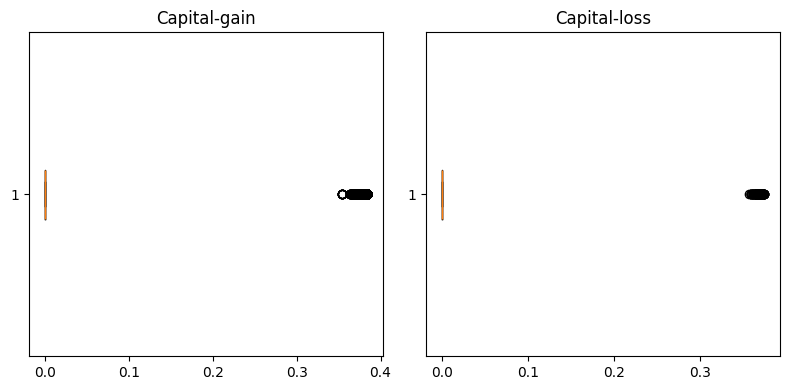

In [293]:
adult_df['capital-gain'] = adult_df['capital-gain'].apply(lambda x: np.log1p(x))
adult_df['capital-loss'] = adult_df['capital-loss'].apply(lambda x: np.log1p(x))

fig, axes = plt.subplots(1,2,figsize=(8,4))
axes[0].boxplot(x=adult_df['capital-gain'],vert=False)
axes[0].set_title('Capital-gain')
axes[1].boxplot(x=adult_df['capital-loss'],vert=False)
axes[1].set_title('Capital-loss')
plt.tight_layout()
plt.show()

#### <font color='blue'>3. Isolation Forest</font>
##### Isolation Forest is an unsupervised anomaly detection algorithm that identifies outliers by isolating them using an ensemble of binary decision trees. It works by randomly splitting data points until they are isolated, with anomalies typically requiring fewer splits than normal data points. The algorithm is known for its speed and efficiency, especially on large datasets. 

In [271]:
from sklearn.ensemble import IsolationForest

numerical_columns = list(adult_df.select_dtypes(include='number'))
iso = IsolationForest(contamination=0.01, random_state=42)
outliers = iso.fit_predict(adult_df[numerical_columns])
adult_df['outlier'] = outliers

# Option to remove
#df_clean = adult_df[adult_df['outlier'] == 1].drop('outlier', axis=1)
adult_df['outlier'].value_counts()

outlier
 1    48324
-1      489
Name: count, dtype: int64

In [272]:
adult_df[adult_df['outlier']==-1]

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,outlier
96,48,self-emp-not-inc,16,married-civ-spouse,prof-specialty,husband,white,True,0.000000,7.551187,60,united-states,True,-1
106,17,NaN,6,never-married,other-service,own-child,white,False,10.436935,0.000000,32,united-states,False,-1
157,71,self-emp-not-inc,10,separated,sales,unmarried,black,True,0.000000,7.504942,2,united-states,False,-1
222,90,private,9,never-married,other-service,not-in-family,black,True,0.000000,7.699389,40,united-states,False,-1
272,50,self-emp-not-inc,14,married-civ-spouse,farming-fishing,husband,white,True,7.786552,0.000000,98,united-states,False,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48157,65,private,4,widowed,other-service,not-in-family,white,False,0.000000,8.063378,60,puerto-rico,False,-1
48473,68,private,10,married-civ-spouse,adm-clerical,husband,white,True,0.000000,7.407924,10,united-states,True,-1
48629,59,self-emp-inc,15,married-civ-spouse,exec-managerial,husband,white,True,11.512925,0.000000,84,united-states,True,-1
48644,54,private,16,widowed,other-service,unmarried,white,True,0.000000,7.813187,40,united-states,True,-1


In [273]:
adult_df_cleaned = adult_df[adult_df['outlier'] == 1].drop('outlier', axis=1)

In [274]:
adult_df_cleaned.shape

(48324, 13)

### <font color='blue'> Feature Engineering

#### Feature engineering is the process of transforming raw data into features that are suitable for machine learning models. In other words, it is the process of selecting, extracting, and transforming the most relevant features from the available data to build more accurate and efficient machine learning models.

In the context of machine learning,

•	a feature (also known as a variable or attribute) is an individual measurable property or characteristic of a data point that is used as input for a machine learning algorithm.

•	Features can be numerical, categorical, or text-based, and they represent different aspects of the data that are relevant to the problem

Processes Involved in Feature Engineering:

**1. Feature Creation**

Feature Creation is the process of generating new features based on domain knowledge or by observing patterns in the data. It is a form of feature engineering that can significantly improve the performance of a machine-learning model.

**Types of Feature Creation:**

**Domain-Specific**: Creating new features based on domain knowledge, such as creating features based on business rules or industry standards.

**Data-Driven:** Creating new features by observing patterns in the data, such as calculating aggregations or creating interaction features.

**Synthetic:** Generating new features by combining existing features or synthesizing new data points.

**2. Feature Transformation**

Feature Transformation is the process of transforming the features into a more suitable representation for the machine learning model. This is done to ensure that the model can effectively learn from the data.

**Types of Feature Transformation:**

**Normalization:** Rescaling the features to have a similar range, such as between 0 and 1, to prevent some features from dominating others.

**Scaling:** Scaling is a technique used to transform numerical variables to have a similar scale, so that they can be compared more easily. Rescaling the features to have a similar scale, such as having a standard deviation of 1, to make sure the model considers all features equally.

**Encoding:** Transforming categorical features into a numerical representation. Examples are one-hot encoding and label encoding.

**Transformation:** Transforming the features using mathematical operations to change the distribution or scale of the features. Examples are logarithmic, square root, and reciprocal transformations. Apply mathematical transformations like log, square root, or Box-Cox to make the data more normally distributed, which can help in reducing the impact of outliers.

##### <font color='blue'>One hot encoding
   <font color='blue'> One-hot encoding is a process that transforms categorical data into a numerical format suitable for machine learning algorithms. It creates a binary vector for each category, where a '1' indicates the presence of that category and '0' indicates its absence. 

In [275]:
adult_df_cleaned['income'].value_counts()

income
False    36906
True     11418
Name: count, dtype: int64

In [276]:
adult_df_cleaned.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [277]:
adult_df_cleaned['native-country'].unique()

array(['united-states', 'cuba', 'other', 'india', 'mexico', 'puerto-rico',
       'canada', 'germany', 'philippines', 'el-salvador', 'china'],
      dtype=object)

In [278]:
adult_df_cleaned.to_csv('Adult_income_cleaned.csv')

In [279]:
df_onehot_encoded = pd.get_dummies(adult_df_cleaned,drop_first=True)
corr_matrix = df_onehot_encoded.corr()
corr_matrix

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_local-gov,workclass_never-worked,workclass_private,...,native-country_china,native-country_cuba,native-country_el-salvador,native-country_germany,native-country_india,native-country_mexico,native-country_other,native-country_philippines,native-country_puerto-rico,native-country_united-states
age,1.000000,0.027354,0.085724,0.105933,0.023659,0.081762,0.227477,0.060018,-0.017621,-0.189049,...,0.010110,0.031852,-0.022894,-0.002055,-0.001281,-0.049505,-0.000215,0.005753,0.005466,0.014365
education-num,0.027354,1.000000,0.005408,0.124404,0.069898,0.140861,0.326467,0.096891,-0.014900,-0.158326,...,0.024729,-0.014364,-0.074116,0.019126,0.054663,-0.221848,-0.026424,0.021453,-0.041103,0.123809
sex,0.085724,0.005408,1.000000,0.063903,0.039267,0.230631,0.212805,-0.041812,-0.002803,-0.059363,...,0.007013,-0.003881,-0.001344,-0.011580,0.025945,0.031424,-0.008089,-0.010599,-0.008833,-0.007512
capital-gain,0.105933,0.124404,0.063903,1.000000,-0.061113,0.082228,0.285385,0.004825,-0.004584,-0.042102,...,-0.001981,-0.004221,-0.007655,0.006314,0.006184,-0.022431,-0.008566,-0.000966,-0.007129,0.018221
capital-loss,0.023659,0.069898,0.039267,-0.061113,1.000000,0.044805,0.129648,0.011036,-0.003311,-0.018911,...,0.010983,-0.001759,-0.006560,-0.005808,0.002007,-0.018844,-0.007037,0.001847,0.000304,0.013053
hours-per-week,0.081762,0.140861,0.230631,0.082228,0.044805,1.000000,0.225831,0.000329,-0.052433,-0.084698,...,-0.006245,-0.001531,-0.017464,0.002487,0.005645,-0.003069,0.000359,-0.005254,-0.007049,0.007840
income,0.227477,0.326467,0.212805,0.285385,0.129648,0.225831,1.000000,0.031468,-0.008766,-0.110179,...,0.006850,0.001052,-0.021483,0.005108,0.022254,-0.061426,-0.017402,0.010318,-0.017916,0.036438
workclass_local-gov,0.060018,0.096891,-0.041812,0.004825,0.011036,0.000329,0.031468,1.000000,-0.004254,-0.454254,...,-0.007668,-0.002212,-0.008185,0.001453,-0.011448,-0.024709,-0.023057,-0.005634,0.000580,0.035217
workclass_never-worked,-0.017621,-0.014900,-0.002803,-0.004584,-0.003311,-0.052433,-0.008766,-0.004254,1.000000,-0.026522,...,-0.000819,-0.000846,-0.000900,-0.001026,-0.000917,-0.002237,-0.003097,-0.001281,-0.000977,0.004878
workclass_private,-0.189049,-0.158326,-0.059363,-0.042102,-0.018911,-0.084698,-0.110179,-0.454254,-0.026522,1.000000,...,0.002662,-0.001518,0.023162,-0.000554,-0.004439,0.050458,0.020410,0.012682,0.009369,-0.047475


In [280]:
df_onehot_encoded.columns

Index(['age', 'education-num', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'income', 'workclass_local-gov',
       'workclass_never-worked', 'workclass_private', 'workclass_self-emp-inc',
       'workclass_self-emp-not-inc', 'workclass_state-gov',
       'workclass_without-pay', 'marital-status_married-af-spouse',
       'marital-status_married-civ-spouse',
       'marital-status_married-spouse-absent', 'marital-status_never-married',
       'marital-status_separated', 'marital-status_widowed',
       'occupation_craft-repair', 'occupation_exec-managerial',
       'occupation_farming-fishing', 'occupation_handlers-cleaners',
       'occupation_machine-op-inspct', 'occupation_other-service',
       'occupation_prof-specialty', 'occupation_sales',
       'occupation_transport-moving', 'relationship_not-in-family',
       'relationship_other-relative', 'relationship_own-child',
       'relationship_unmarried', 'relationship_wife',
       'race_asian-pac-islander', 'rac

In [281]:
df_onehot_encoded.head()

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_local-gov,workclass_never-worked,workclass_private,...,native-country_china,native-country_cuba,native-country_el-salvador,native-country_germany,native-country_india,native-country_mexico,native-country_other,native-country_philippines,native-country_puerto-rico,native-country_united-states
0,39,13,True,7.684784,0.0,40,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,50,13,True,0.000000,0.0,13,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,38,9,True,0.000000,0.0,40,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
3,53,7,True,0.000000,0.0,40,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,28,13,False,0.000000,0.0,40,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False


In [282]:
df_onehot_encoded.dtypes

age                                       int64
education-num                             int64
sex                                        bool
capital-gain                            float64
capital-loss                            float64
hours-per-week                            int64
income                                     bool
workclass_local-gov                        bool
workclass_never-worked                     bool
workclass_private                          bool
workclass_self-emp-inc                     bool
workclass_self-emp-not-inc                 bool
workclass_state-gov                        bool
workclass_without-pay                      bool
marital-status_married-af-spouse           bool
marital-status_married-civ-spouse          bool
marital-status_married-spouse-absent       bool
marital-status_never-married               bool
marital-status_separated                   bool
marital-status_widowed                     bool
occupation_craft-repair                 

In [283]:
df_onehot_encoded.isnull().sum()

age                                     0
education-num                           0
sex                                     0
capital-gain                            0
capital-loss                            0
hours-per-week                          0
income                                  0
workclass_local-gov                     0
workclass_never-worked                  0
workclass_private                       0
workclass_self-emp-inc                  0
workclass_self-emp-not-inc              0
workclass_state-gov                     0
workclass_without-pay                   0
marital-status_married-af-spouse        0
marital-status_married-civ-spouse       0
marital-status_married-spouse-absent    0
marital-status_never-married            0
marital-status_separated                0
marital-status_widowed                  0
occupation_craft-repair                 0
occupation_exec-managerial              0
occupation_farming-fishing              0
occupation_handlers-cleaners      

#### <font color='blue'> Standardization

In [284]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_columns = list(df_onehot_encoded.select_dtypes(include='number'))
df_standardized = df_onehot_encoded.copy()
df_standardized[numerical_columns] = scaler.fit_transform(df_onehot_encoded[numerical_columns])

# Check the result
df_standardized.describe()


,age,education-num,capital-gain,capital-loss,hours-per-week
count,4.832400e+04,4.832400e+04,4.832400e+04,4.832400e+04,4.832400e+04
mean,2.911337e-17,-2.538598e-16,4.558154e-17,-7.616529e-17,7.910603e-17
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.587200e+00,-3.570400e+00,-2.908839e-01,-2.100958e-01,-3.326885e+00
25%,-7.723413e-01,-4.204022e-01,-2.908839e-01,-2.100958e-01,-3.086860e-02
50%,-1.056384e-01,-2.665250e-02,-2.908839e-01,-2.100958e-01,-3.086860e-02
75%,6.351426e-01,7.608470e-01,-2.908839e-01,-2.100958e-01,3.811334e-01
max,3.820501e+00,2.335846e+00,4.533842e+00,5.337878e+00,4.830755e+00


In [285]:
df_standardized.to_csv('Adult_income_standardized.csv')

#### <font color='blue'> Normalization

In [286]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_normalized = df_onehot_encoded.copy()
df_normalized[numerical_columns] = scaler.fit_transform(df_onehot_encoded[numerical_columns])

# Check the result
df_normalized.describe()


,age,education-num,capital-gain,capital-loss,hours-per-week
count,48324.000000,48324.000000,48324.000000,48324.000000,48324.000000
mean,0.293507,0.604513,0.060290,0.037869,0.407824
std,0.184923,0.169314,0.207268,0.180248,0.122586
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.533333,0.000000,0.000000,0.404040
50%,0.273973,0.600000,0.000000,0.000000,0.404040
75%,0.410959,0.733333,0.000000,0.000000,0.454545
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [287]:
df_normalized.to_csv('Adult_income_normalized.csv')